# 02 — A single self-attention head

We add one mechanism: a single head of causal self-attention between the embeddings and the output head. Each position now emits a **query**, a **key**, and a **value**; the output at position *t* is a weighted average of the values at positions ≤ *t*, with weights set by query·key affinity. This is the first time information can move *between* positions.

We also add a **position embedding** — attention is permutation-invariant, so without it the model cannot tell `ab` from `ba`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import torch, matplotlib.pyplot as plt
from gpt import make_dataset, train, generate, set_seed, TrainConfig

ds = make_dataset()
print("vocab:", ds.vocab_size, "| train tokens:", len(ds.train_data), "| val tokens:", len(ds.val_data))

vocab: 65 | train tokens: 1003854 | val tokens: 111540


In [2]:
import torch.nn as nn
from torch.nn import functional as F
from gpt.layers import Head

N_EMBD, BLOCK = 64, 32

class SingleHeadLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, N_EMBD)
        self.pos = nn.Embedding(BLOCK, N_EMBD)
        self.sa  = Head(N_EMBD, N_EMBD, BLOCK, 0.0)   # one head spanning the full width
        self.lm_head = nn.Linear(N_EMBD, vocab_size)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok(idx) + self.pos(torch.arange(T))
        x = self.sa(x)
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        Bv, Tv, Cv = logits.shape
        return logits, F.cross_entropy(logits.view(Bv*Tv, Cv), targets.view(Bv*Tv))

g = set_seed(1337)
model = SingleHeadLM(ds.vocab_size)
print(sum(p.numel() for p in model.parameters()), "parameters")
cfg = TrainConfig(max_iters=5000, eval_interval=250, eval_iters=200, batch_size=16)
history = train(model, ds, block_size=BLOCK, cfg=cfg, generator=g)

22721 parameters


step 0: train loss 4.1827, val loss 4.1868


step 250: train loss 2.7410, val loss 2.7692


step 500: train loss 2.5874, val loss 2.6045


step 750: train loss 2.5089, val loss 2.5190


...

step 4000: train loss 2.3396, val loss 2.3680


step 4250: train loss 2.3363, val loss 2.3644


step 4500: train loss 2.3377, val loss 2.3654


step 4750: train loss 2.3291, val loss 2.3616


step 4999: train loss 2.3261, val loss 2.3556


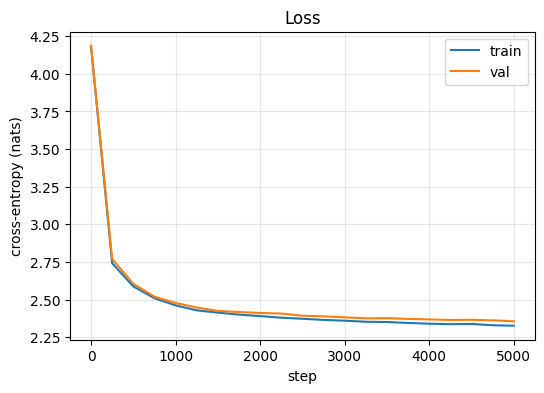

final: {'step': 4999, 'train': 2.3260581493377686, 'val': 2.355632781982422}

If akn eas lp Nand hy
Fallllar athe shery hinghathid, heries st:
Buur thalt, dewt.
Buch I GUKINGnid You cen and brice scled the weroned to wleandis cefe Ise lort onge!
CAMENENOYO:
Wheiver, nald ly, Ey calthis cif ust isechewrand, Parth youeres ghsighrant shen lan ienregoim fror st tint ngo wereto me


In [3]:
steps = [h["step"] for h in history]
plt.figure(figsize=(6,4))
plt.plot(steps, [h["train"] for h in history], label="train")
plt.plot(steps, [h["val"] for h in history], label="val")
plt.xlabel("step"); plt.ylabel("cross-entropy (nats)"); plt.legend()
plt.title("Loss"); plt.grid(alpha=0.3); plt.show()
print("final:", history[-1])

# sample
out = generate(model, torch.zeros((1,1), dtype=torch.long), max_new_tokens=300, block_size=BLOCK)
print(ds.tokenizer.decode(out[0].tolist()))

**Takeaway.** One attention head drops val loss from ~2.48 to about **2.36 nats**. A single head with no feed-forward network and no depth is a weak learner, but the direction is unambiguous: even minimal context helps. The next step adds parallel heads and per-token computation.